## 1. Import Libraries

In [5]:
#Import libraries
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

from itertools import product

# for better resolution plots
%config InlineBackend.figure_format = 'retina'

#Load the data
df = pd.read_csv(
    "project_info/data/acdc_dataset.csv",
    sep= ";",
)

df.head()

,member_id,age,gender,industry,country,is_team_account,n_colleagues_on_account,plan_tier,plan_days_per_week,membership_start,...,uses_event_space,uses_guest_passes,uses_print,uses_mail_handling,uses_phone_booths,uses_day_passes,uses_storage,uses_bike_locker,n_renewals,lifetime_value
0,CW000001,38.0,Female,Information Technology,Portugal,False,0,flex,3,2021-08-01,...,False,True,0,False,True,True,False,False,2,4477.97
1,CW000002,38.0,Male,Information Technology,Portugal,True,2,HOT_DESK,2,2023-11-24,...,False,False,0,True,False,False,False,False,0,165.86
2,CW000003,43.0,Male,Education,DE,True,1,flex,3,2021-12-03,...,False,False,0,False,False,False,False,False,1,4486.17
3,CW000004,38.0,F,Legal,portugal,False,0,flex,3,2022-01-02,...,False,False,0,False,False,False,False,False,0,258.63
4,CW000005,45.0,Female,Information Technology,United Kingdom,False,0,hot_desk,2,2023-10-24,...,False,False,0,False,False,True,False,False,0,335.74


## 2. Initial data overview

In [6]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Unique member IDs: {df['member_id'].nunique():,}")
df.info()


Rows: 15,465
Columns: 31
Unique member IDs: 15,450
<class 'pandas.DataFrame'>
RangeIndex: 15465 entries, 0 to 15464
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   member_id                    15465 non-null  str    
 1   age                          14907 non-null  float64
 2   gender                       14935 non-null  str    
 3   industry                     15465 non-null  str    
 4   country                      15035 non-null  str    
 5   is_team_account              15465 non-null  bool   
 6   n_colleagues_on_account      15465 non-null  int64  
 7   plan_tier                    15360 non-null  str    
 8   plan_days_per_week           15465 non-null  int64  
 9   membership_start             15465 non-null  str    
 10  membership_end               15465 non-null  str    
 11  last_badge_swipe             15465 non-null  str    
 12  days_since_last_visit        15465

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
member_id,15465,15450,CW015101,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,14907.0,NaN,NaN,NaN,34.858724,10.394649,1.0,29.0,34.0,40.0,149.0
gender,14935,12,Female,7414,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry,15465,43,Information Technology,3322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,15035,33,Portugal,9959,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_team_account,15465,2,False,11112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_colleagues_on_account,15465.0,NaN,NaN,NaN,0.537019,1.177668,-1.0,0.0,0.0,1.0,9.0
plan_tier,15360,19,flex,5182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plan_days_per_week,15465.0,NaN,NaN,NaN,3.387262,1.458818,0.0,2.0,3.0,5.0,9.0
membership_start,15465,1539,2021-01-01,560,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Initial observation
The dataset contains 15,465 observations and 31 variables covering member characteristics, membership plans, usage behavior, service usage, renewals, and customer value. The initial summary shows that several variables contain missing values, represented as NaN, including demographic and behavioral features. Some numerical variables also show very wide ranges between their minimum and maximum values, suggesting the possible presence of outliers or data-quality issues. These aspects will be examined in more detail during the data-quality assessment.


## 3. Data quality assessment

### 3.1 Missing values and duplicates

In [8]:
missing = pd.DataFrame({
    "missing_n": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100 #mean works because isna() gives True for missing values and False for non missing
}).query("missing_n > 0").sort_values("missing_pct", ascending=False)

missing


,missing_n,missing_pct
meeting_room_hours,1298,8.393146
guest_passes_issued,1271,8.218558
lifetime_value,1040,6.724863
age,558,3.608147
gender,530,3.427093
country,430,2.780472
plan_tier,105,0.678952


In [9]:
print("Duplicated rows:", df.duplicated().sum())
print("Duplicated member IDs:", df["member_id"].duplicated().sum())

Duplicated rows: 15
Duplicated member IDs: 15


In [10]:
dup_ids = df.loc[df["member_id"].duplicated(keep=False)].sort_values("member_id")
dup_ids.head(20)

,member_id,age,gender,industry,country,is_team_account,n_colleagues_on_account,plan_tier,plan_days_per_week,membership_start,...,uses_event_space,uses_guest_passes,uses_print,uses_mail_handling,uses_phone_booths,uses_day_passes,uses_storage,uses_bike_locker,n_renewals,lifetime_value
959,CW000935,22.0,Female,Unknown,Portugal,False,0,FLEX,3,2022-12-18,...,False,True,0,False,False,False,False,False,0,505.28
15453,CW000935,22.0,Female,Unknown,Portugal,False,0,FLEX,3,2022-12-18,...,False,True,0,False,False,False,False,False,0,505.28
1428,CW001390,44.0,Male,UNKNOWN,Portugal,False,0,hot_desk,2,28/10/2022,...,False,True,0,False,False,False,False,False,0,231.86
15454,CW001390,44.0,Male,UNKNOWN,Portugal,False,0,hot_desk,2,28/10/2022,...,False,True,0,False,False,False,False,False,0,231.86
3985,CW003868,28.0,Female,Design & Creative,Portugal,True,1,hot_desk,2,2023-12-27,...,False,False,0,False,False,False,False,False,0,18.14
15462,CW003868,28.0,Female,Design & Creative,Portugal,True,1,hot_desk,2,2023-12-27,...,False,False,0,False,False,False,False,False,0,18.14
5441,CW005287,19.0,Female,Information Technology,Germany,False,0,private_office,7,2021-04-29,...,False,False,0,True,True,False,True,False,0,20683.24
15461,CW005287,19.0,Female,Information Technology,Germany,False,0,private_office,7,2021-04-29,...,False,False,0,True,True,False,True,False,0,20683.24
6011,CW005845,35.0,Female,FINANCE,Portugal,True,3,dedicated_desk,5,2021-10-05,...,False,False,0,False,False,False,False,False,4,9403.99
15456,CW005845,35.0,Female,FINANCE,Portugal,True,3,dedicated_desk,5,2021-10-05,...,False,False,0,False,False,False,False,False,4,9403.99


Missing values must be handled because most clustering algorithms cannot work directly with them. Duplicates may give repeated customers extra influence, so they should be investigated before modeling.


### 3.2 Inconsistent category labels

In [12]:
for col in ["gender", "plan_tier", "country", "industry"]:
    print("\n---", col, "---")
    print(df[col].value_counts(dropna=False).head(20))


--- gender ---
gender
Female     7414
Male       6172
NaN         530
Other       465
female      169
F           143
 Female     141
M           138
male        132
 Male       129
other        15
 Other        9
O             8
Name: count, dtype: int64

--- plan_tier ---
plan_tier
flex              5182
hot_desk          4974
full_time         2323
dedicated_desk    1481
private_office     630
Flex               138
FLEX               133
NaN                105
HOT_DESK            82
Hot Desk            80
hotdesk             79
fulltime            64
FULL_TIME           49
Full Time           39
DEDICATED_DESK      27
Dedicated Desk      25
dedicateddesk       19
Private Office      13
privateoffice       12
PRIVATE_OFFICE      10
Name: count, dtype: int64

--- country ---
country
Portugal          9959
United Kingdom    1105
Germany            852
Spain              712
France             506
Netherlands        464
NaN                430
Other (Europe)     429
Ireland            

The raw categorical variables contain capitalization differences, extra spaces, abbreviations, and alternative spellings. These should be standardized before clustering.


### 3.3 Dates and suspicious values

In [13]:
#“For each date column, what is the earliest date, the latest date, how many dates are missing, and how many suspicious 1970-01-01 values appear?”
eda = df.copy()

date_cols = ["membership_start", "membership_end", "last_badge_swipe"]
for col in date_cols:
    eda[col] = pd.to_datetime(eda[col], errors="coerce") #treat these values as dates
    #errors changes that value into NaT

for col in date_cols:
    print(
        col,
        "| min:", eda[col].min(),
        "| max:", eda[col].max(),
        "| missing:", eda[col].isna().sum(),
        "| 1970-01-01:", (eda[col] == pd.Timestamp("1970-01-01")).sum()
    )

membership_start | min: 2021-01-01 00:00:00 | max: 2023-12-30 00:00:00 | missing: 639 | 1970-01-01: 0
membership_end | min: 1970-01-01 00:00:00 | max: 2024-01-01 00:00:00 | missing: 463 | 1970-01-01: 3956
last_badge_swipe | min: 2020-09-06 00:00:00 | max: 2024-04-28 00:00:00 | missing: 639 | 1970-01-01: 0


In [14]:
date_checks = {
    "membership end before start": (
        eda["membership_end"].notna()
        & eda["membership_start"].notna()
        & (eda["membership_end"] < eda["membership_start"])
    ).sum(),
    "last swipe before membership start": (
        eda["last_badge_swipe"].notna()
        & eda["membership_start"].notna()
        & (eda["last_badge_swipe"] < eda["membership_start"])
    ).sum(),
    "last swipe after membership end": (
        eda["last_badge_swipe"].notna()
        & eda["membership_end"].notna()
        & (eda["last_badge_swipe"] > eda["membership_end"])
    ).sum(),
}
pd.Series(date_checks, name="count")

membership end before start           3924
last swipe before membership start      89
last swipe after membership end       3983
Name: count, dtype: int64

Suspicious because in membership_end there is 3956 records that their membership ended in 1970 when membership_start min is 2021, most likely it is a placeholder

In [15]:
checks = {
    "age < 18": (eda["age"] < 18).sum(),
    "age > 100": (eda["age"] > 100).sum(),
    "negative colleagues": (eda["n_colleagues_on_account"] < 0).sum(),
    "plan days outside 1-7": ((eda["plan_days_per_week"] < 1) | (eda["plan_days_per_week"] > 7)).sum(),
    "negative days since visit": (eda["days_since_last_visit"] < 0).sum(),
    "negative total visits": (eda["total_visits"] < 0).sum(),
    "negative meeting-room hours": (eda["meeting_room_hours"] < 0).sum(),
    "negative event-space hours": (eda["event_space_hours"] < 0).sum(),
    "negative guest passes": (eda["guest_passes_issued"] < 0).sum(),
    "negative renewals": (eda["n_renewals"] < 0).sum(),
}
pd.Series(checks, name="count")

age < 18                        98
age > 100                       45
negative colleagues            566
plan days outside 1-7           97
negative days since visit       56
negative total visits           42
negative meeting-room hours     16
negative event-space hours       8
negative guest passes            7
negative renewals               66
Name: count, dtype: int64

## 4. Light standardization for EDA

In [16]:
gender_map = {
    "female": "Female", "f": "Female",
    "male": "Male", "m": "Male",
    "other": "Other", "o": "Other"
}
eda["gender_clean"] = (
    eda["gender"].astype("string").str.strip().str.lower().map(gender_map)
)

eda["plan_tier_clean"] = (
    eda["plan_tier"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .replace({
        "hotdesk": "hot_desk",
        "fulltime": "full_time",
        "dedicateddesk": "dedicated_desk",
        "privateoffice": "private_office"
    })
)

print(eda["gender_clean"].value_counts(dropna=False))
print()
print(eda["plan_tier_clean"].value_counts(dropna=False))

gender_clean
Female    7867
Male      6571
NaN        530
Other      497
Name: count, dtype: int64

plan_tier_clean
flex              5453
hot_desk          5215
full_time         2475
dedicated_desk    1552
private_office     665
<NA>               105
Name: count, dtype: int64[pyarrow]


Country and industry should be standardized too, but the group should inspect all variants and agree on the final mapping rather than automatically guessing.


## 5. Univariate exploration

### 5.1 Outlier Analysis

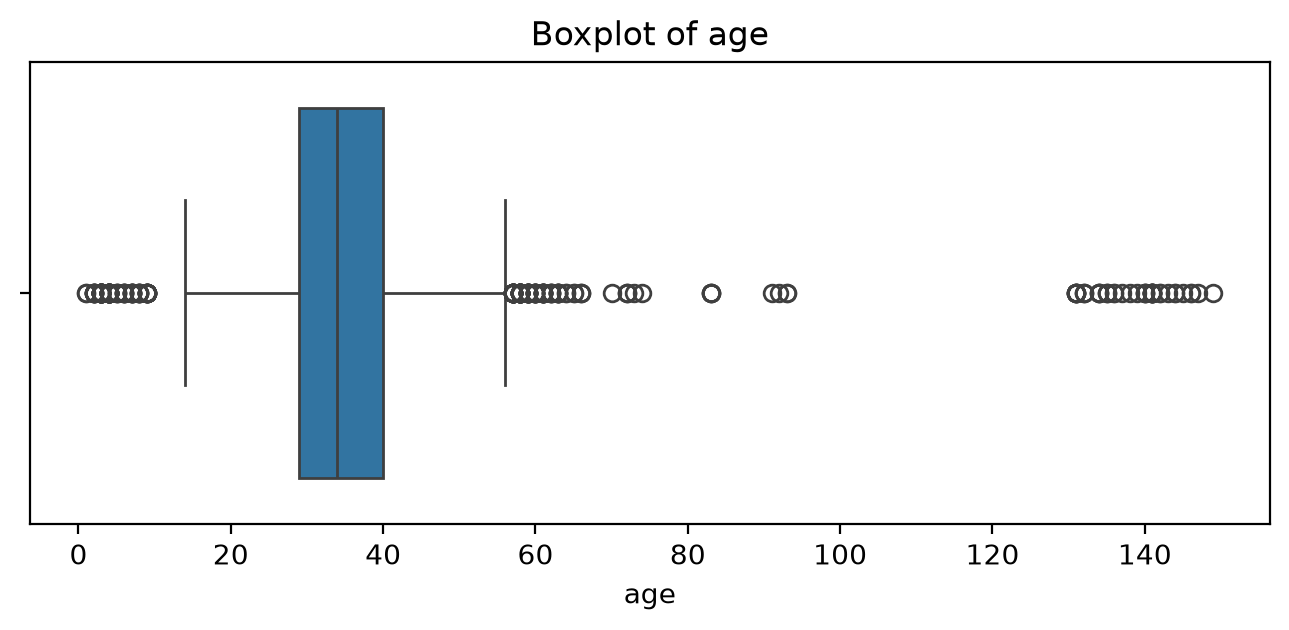

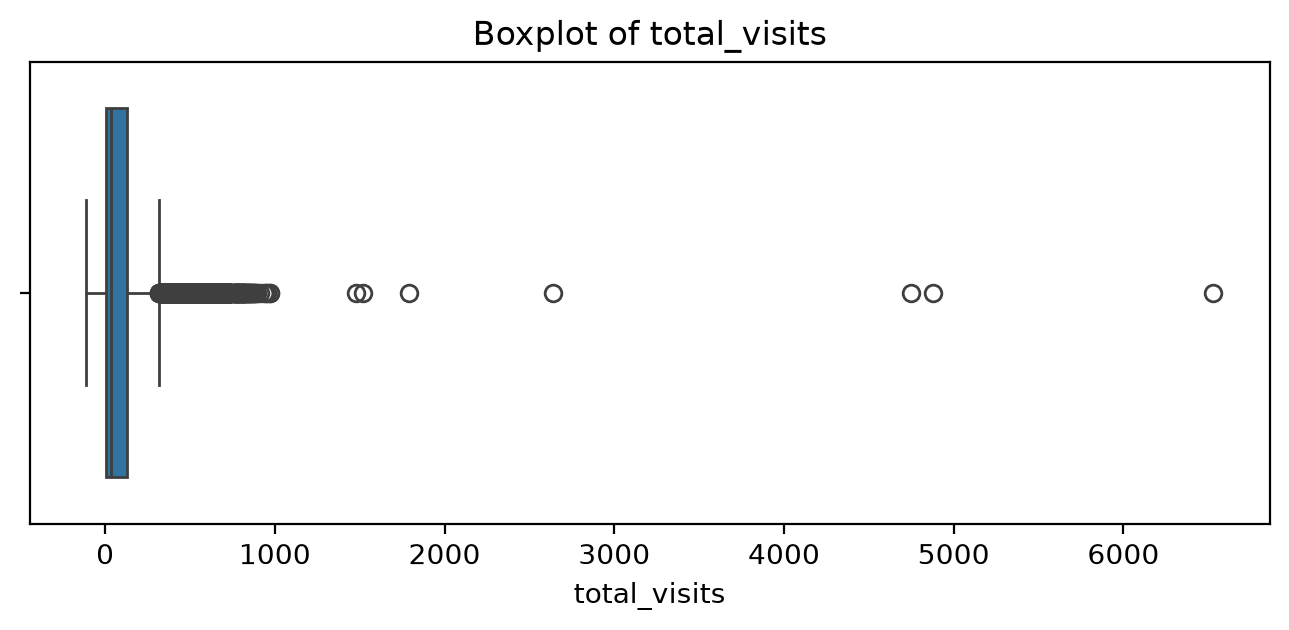

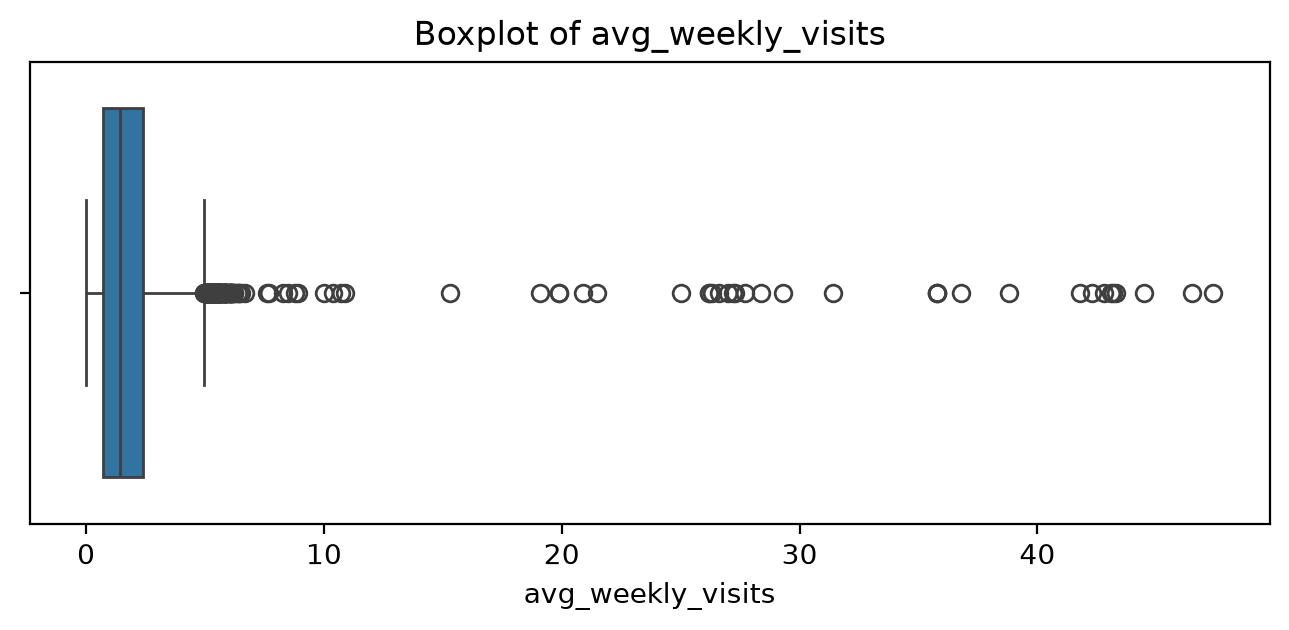

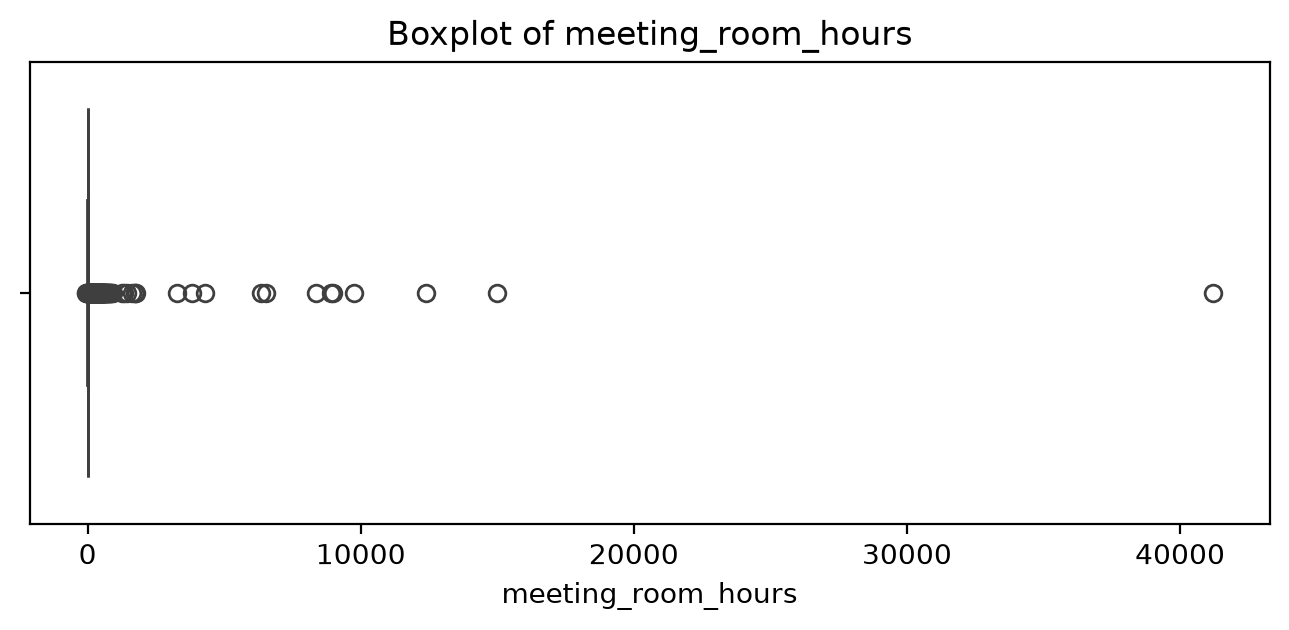

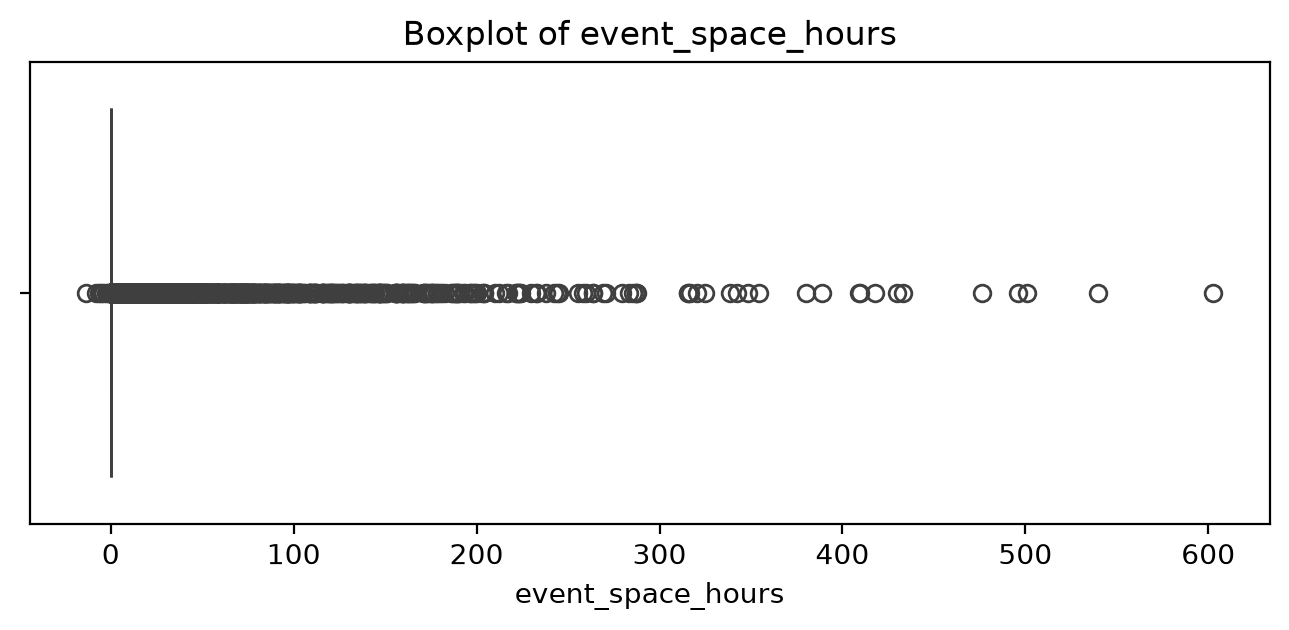

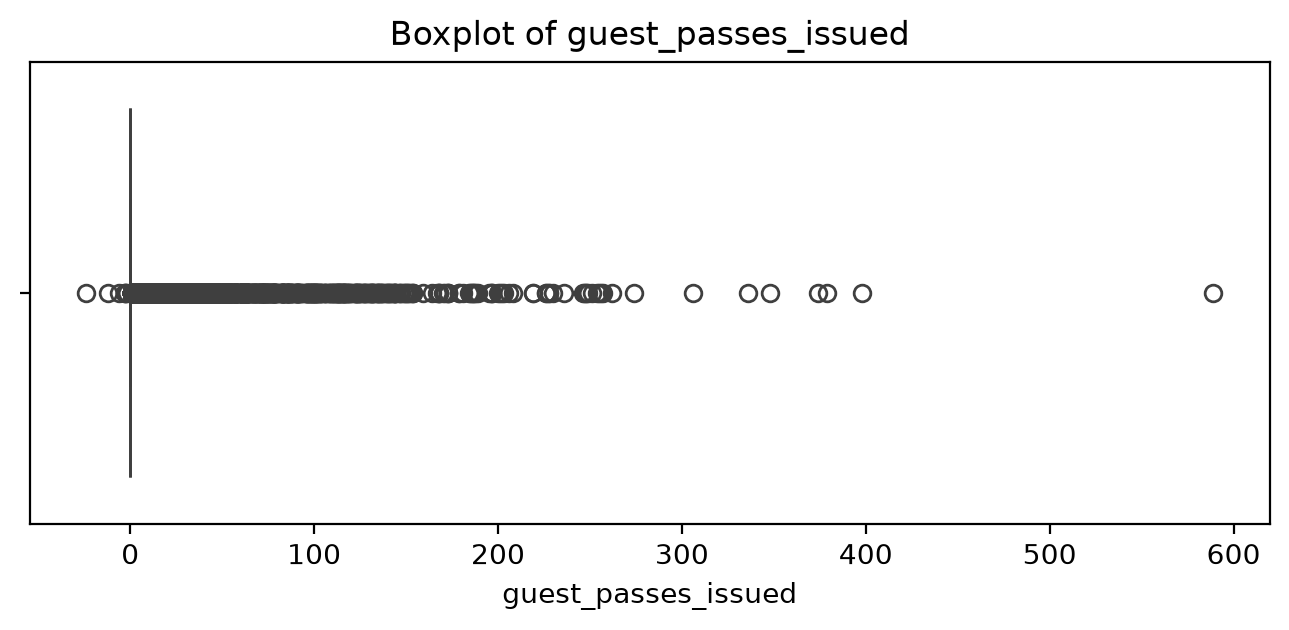

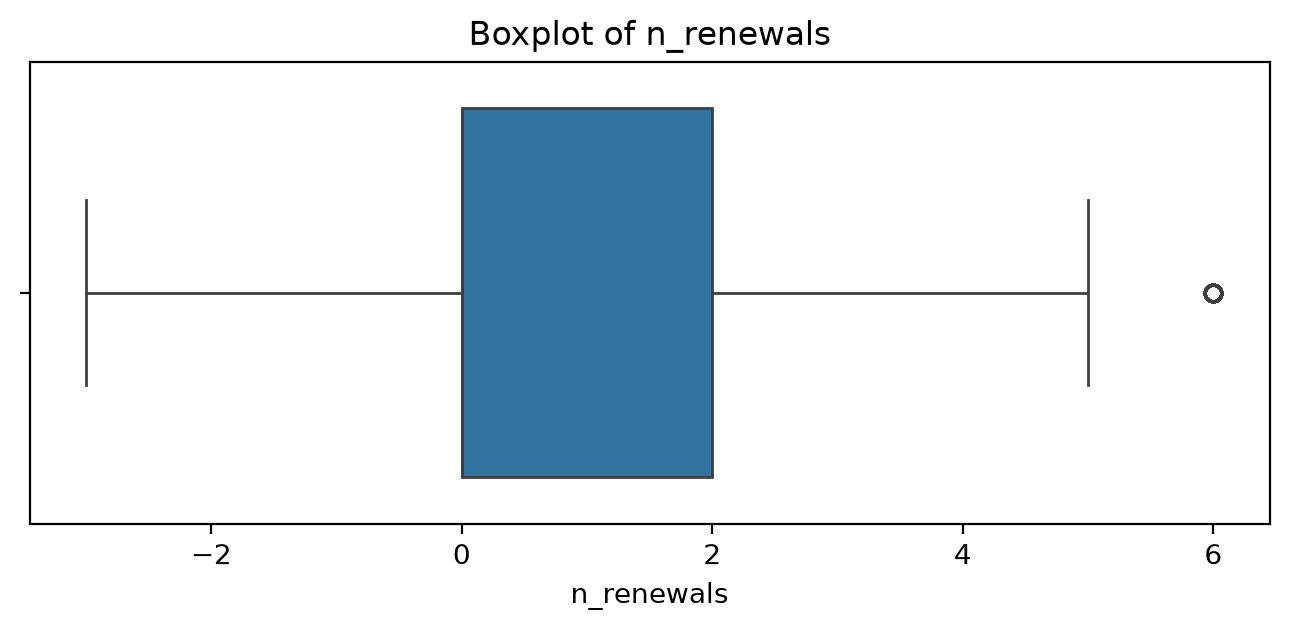

In [18]:
outlier_cols = [
    "age",
    "total_visits",
    "avg_weekly_visits",
    "meeting_room_hours",
    "event_space_hours",
    "guest_passes_issued",
    "n_renewals"
]

for col in outlier_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

For our variables:
- Age: outliers at very low or very high ages may be data-quality problems if they are unrealistic.
- Total visits: high outliers may be genuinely very active or long-term members.
- Average weekly visits: very high outliers may indicate unusually active members, but they should be checked for plausibility.
- Meeting room hours: high outliers may indicate members who use meeting rooms much more than others, which could be a meaningful customer profile.
- Event space hours: same idea; extreme users may represent a distinct behavioral group.
- Guest passes issued: high values may indicate members who frequently bring clients or guests.
- Number of renewals: high positive values may indicate loyal long-term members, while negative values would be a data-quality problem.
  

## 6. Correlation and redundancy

Lets try to apply a Spearman correlation to our data to see which behaviors move together and which variables might be redundant when we later build the clustering model.
Spearman correlation was used because several numerical variables contain extreme values. As a rank-based measure, Spearman is less sensitive to outliers and can identify monotonic relationships that are not necessarily linear.

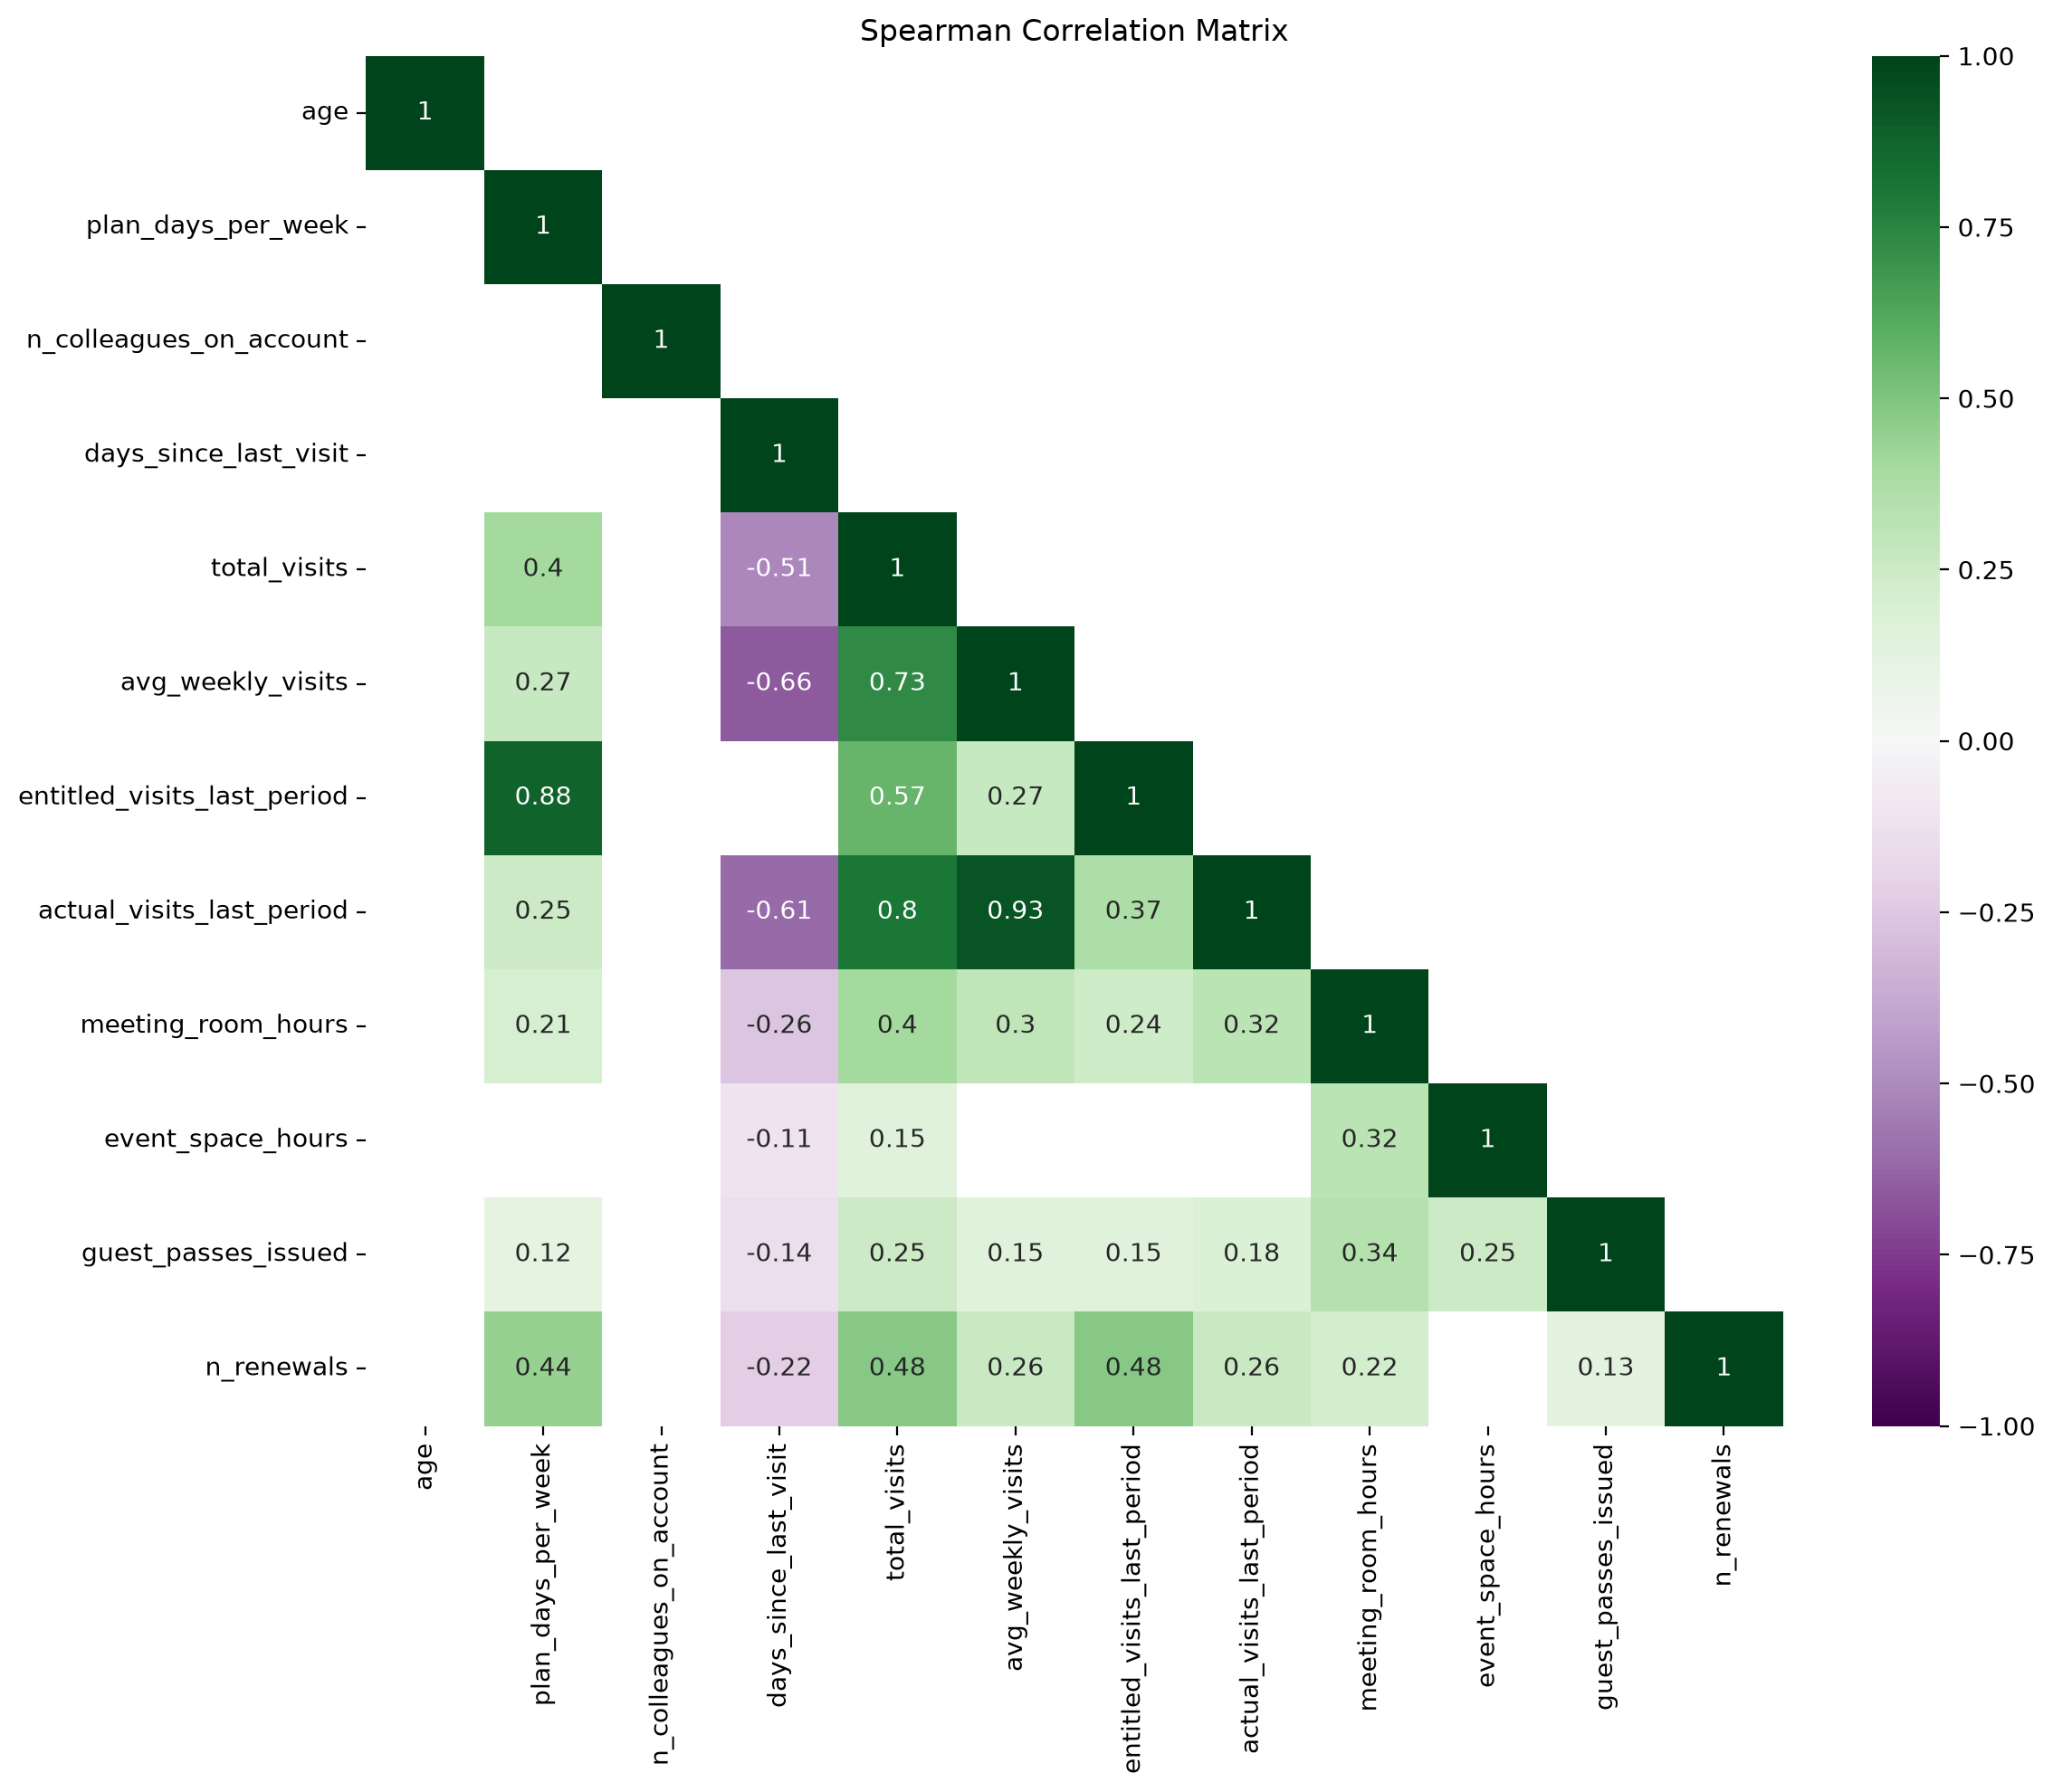

In [20]:
#Variables i want to include in the correlation analysis, aka numeric variables
corr_cols = [
    "age", "plan_days_per_week", "n_colleagues_on_account",
    "days_since_last_visit", "total_visits", "avg_weekly_visits",
    "entitled_visits_last_period", "actual_visits_last_period",
    "meeting_room_hours", "event_space_hours", "guest_passes_issued",
    "n_renewals"
]
corr = df[corr_cols].corr(method="spearman").round(2)
plt.figure(figsize=(12, 10)) #size of the graph
sns.heatmap(
    corr,
    mask=(~np.tril(np.ones_like(corr, dtype=bool))) | (corr.abs() < 0.10),
    #tril hides the upper traingle, upper triangle is True but Seaborn hides True cells, so we add the "~"
    annot=True,#write the correlation value inside each square 
    cmap='PRGn', #colour palette
    center=0,
    vmin=-1,
    vmax=1,
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout() #helps prevent labels from overlapping or being cut off
plt.show()
# also the values close to zero(check distributions because they could still relate to eachother



#avg_weekly_visits ↔ actual_visits_last_period = 0.93
#Members with higher weekly visit frequency generally also have more actual visits in the recent period.
#people who rank high in average weekly visits also rank high on actual visits last period

#days_since_last_visit ↔ avg_weekly_visits = -0.66
#As the number of days since the last visit increases, weekly visit frequency generally decreases.

#Age shows little monotonic(means if one grows the other typically grows or decreases too)
#relationship with all variables according to Spearman correlation but it doesnt mean it has no relationship at all


Spearman correlation was used to examine monotonic relationships between numerical variables. The upper triangle was removed because the correlation matrix is symmetrical, and very weak correlations were hidden to improve readability. Strong correlations may indicate related or potentially redundant variables. However, correlations close to zero do not necessarily indicate the absence of a relationship, as non-linear patterns may still be present and should be investigated through distributions and other visualizations.

### 6.1 Age vs Average weekly visits 

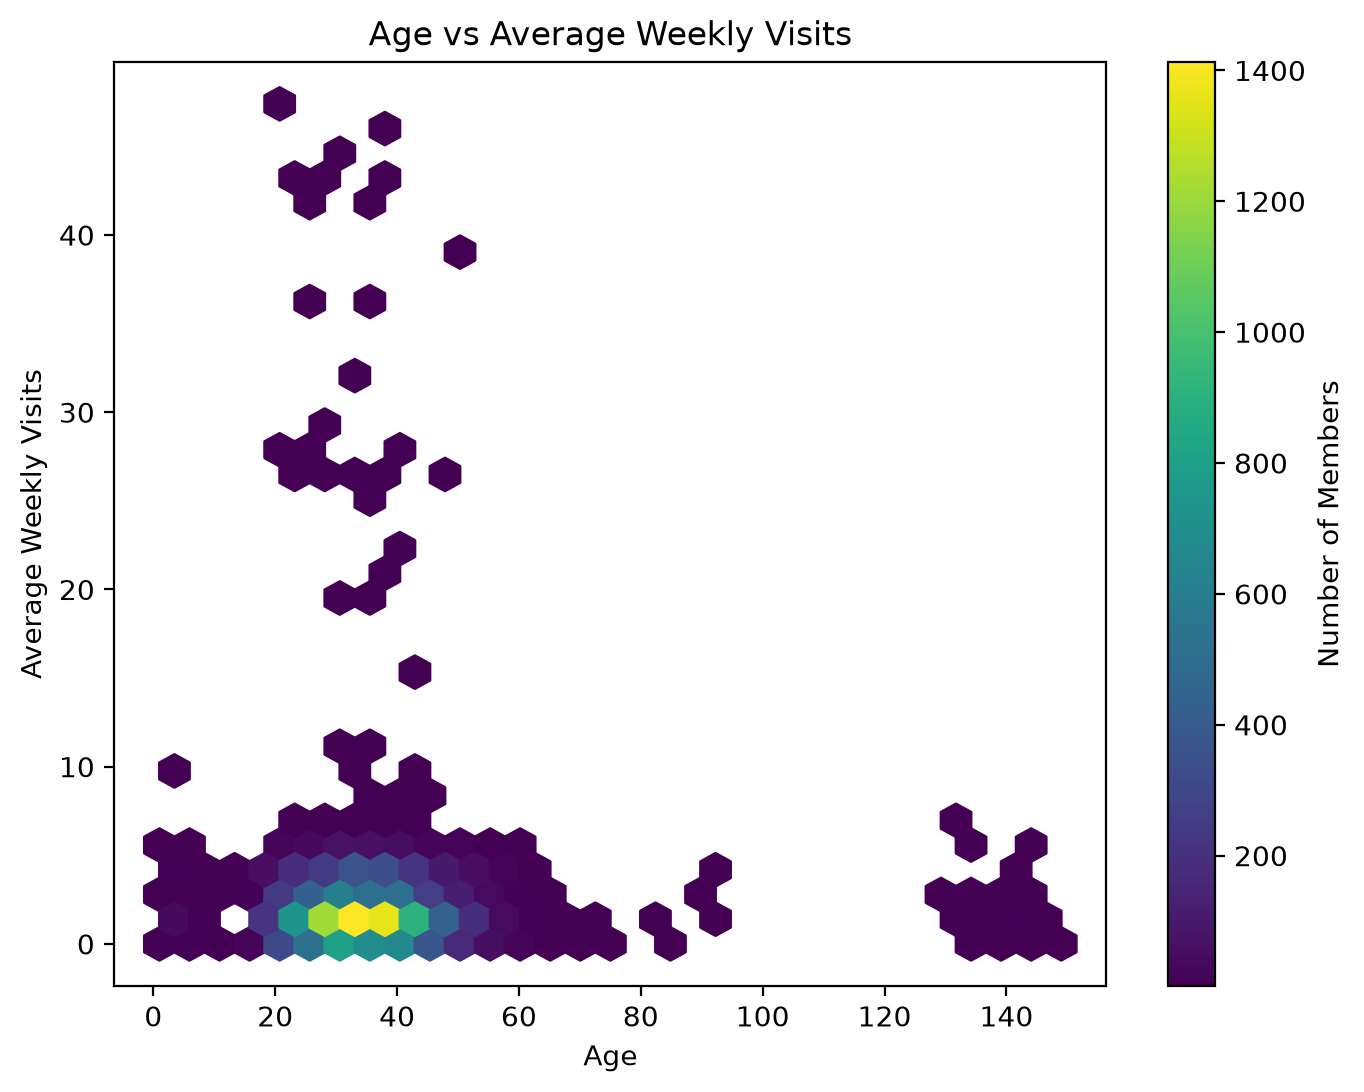

Spearman correlation: 0.01


In [22]:
plt.figure(figsize=(8, 6))

plt.hexbin(
    df["age"],
    df["avg_weekly_visits"],
    gridsize=30,
    cmap="viridis",
    mincnt=1
)

plt.xlabel("Age")
plt.ylabel("Average Weekly Visits")
plt.title("Age vs Average Weekly Visits")

plt.colorbar(label="Number of Members")
plt.show()

rho = df["age"].corr(df["avg_weekly_visits"], method="spearman")
print("Spearman correlation:", round(rho, 2))

The hexbin plot does not suggest a clear increasing or decreasing relationship between age and average weekly visits. Instead, the observations are concentrated in particular areas of the distribution, showing that members with similar ages can have quite different levels of weekly activity.

### Number of colleagues on account vs meeting rooms hours

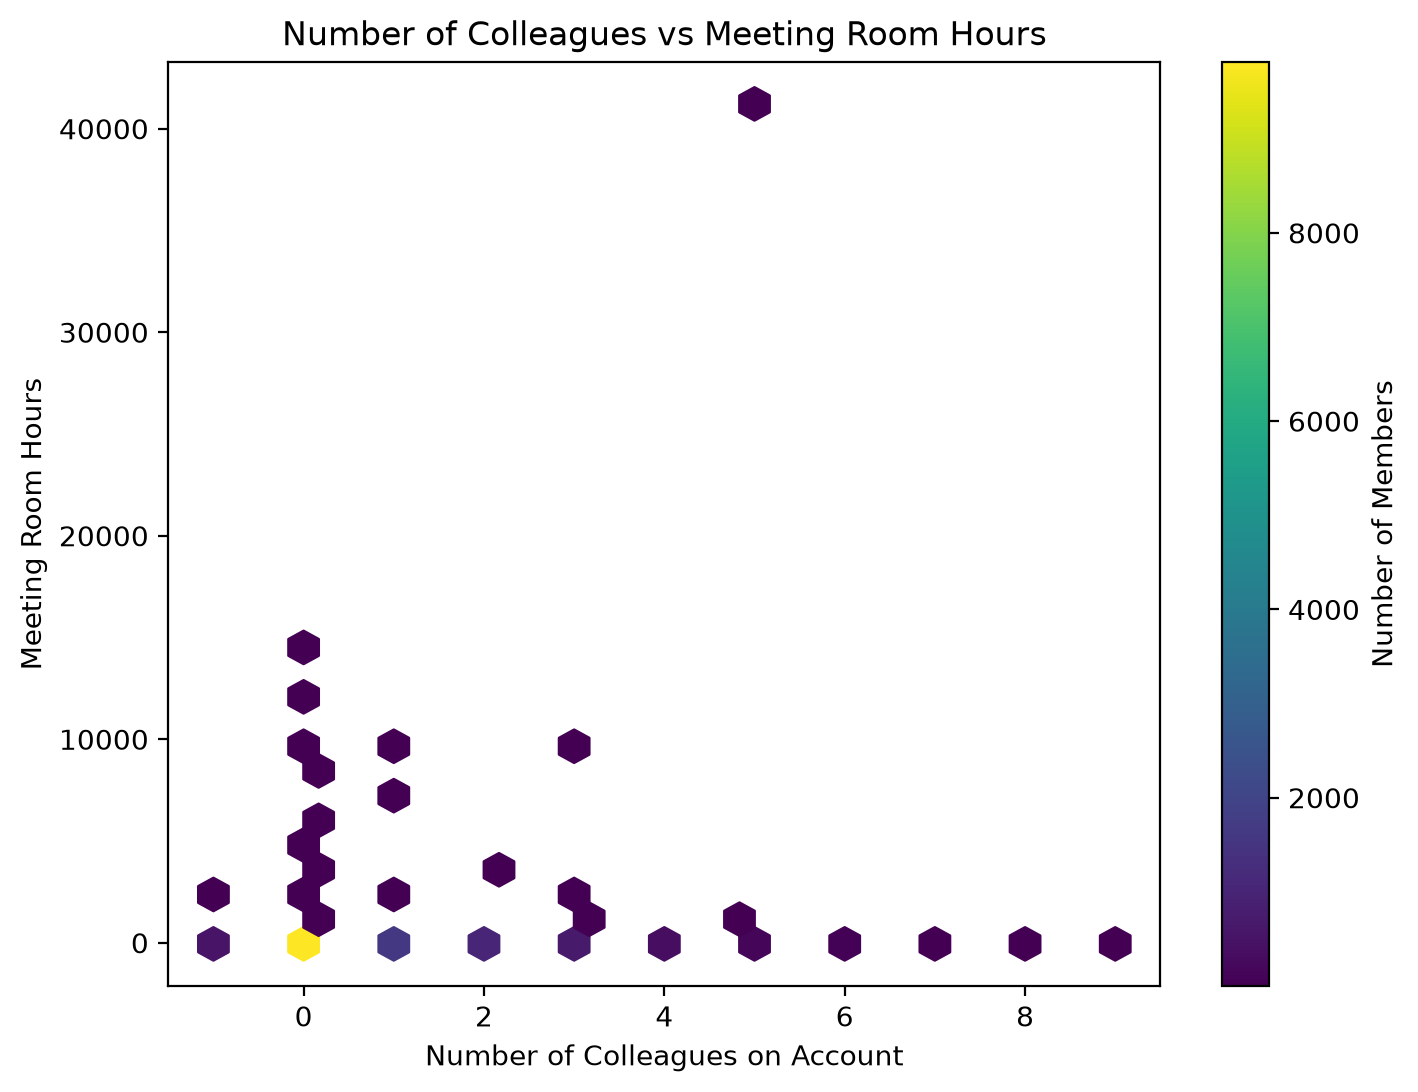

Spearman correlation: 0.01


In [23]:
plt.figure(figsize=(8, 6))

plt.hexbin(
    df["n_colleagues_on_account"],
    df["meeting_room_hours"],
    gridsize=30,
    cmap="viridis",
    mincnt=1
)

plt.xlabel("Number of Colleagues on Account")
plt.ylabel("Meeting Room Hours")
plt.title("Number of Colleagues vs Meeting Room Hours")

plt.colorbar(label="Number of Members")
plt.show()
rho = df["n_colleagues_on_account"].corr(df["meeting_room_hours"], method="spearman")
print("Spearman correlation:", round(rho, 2))

No clear monotonic relationship is visible between the number of colleagues on an account and meeting-room usage. Most members are concentrated around low values for both variables. However, the graph reveals that there is extremely large meeting-room-hour values, plus a negative value for number of colleagues. Those are strong anomalies.

### Event space hours vs Average weekly visits

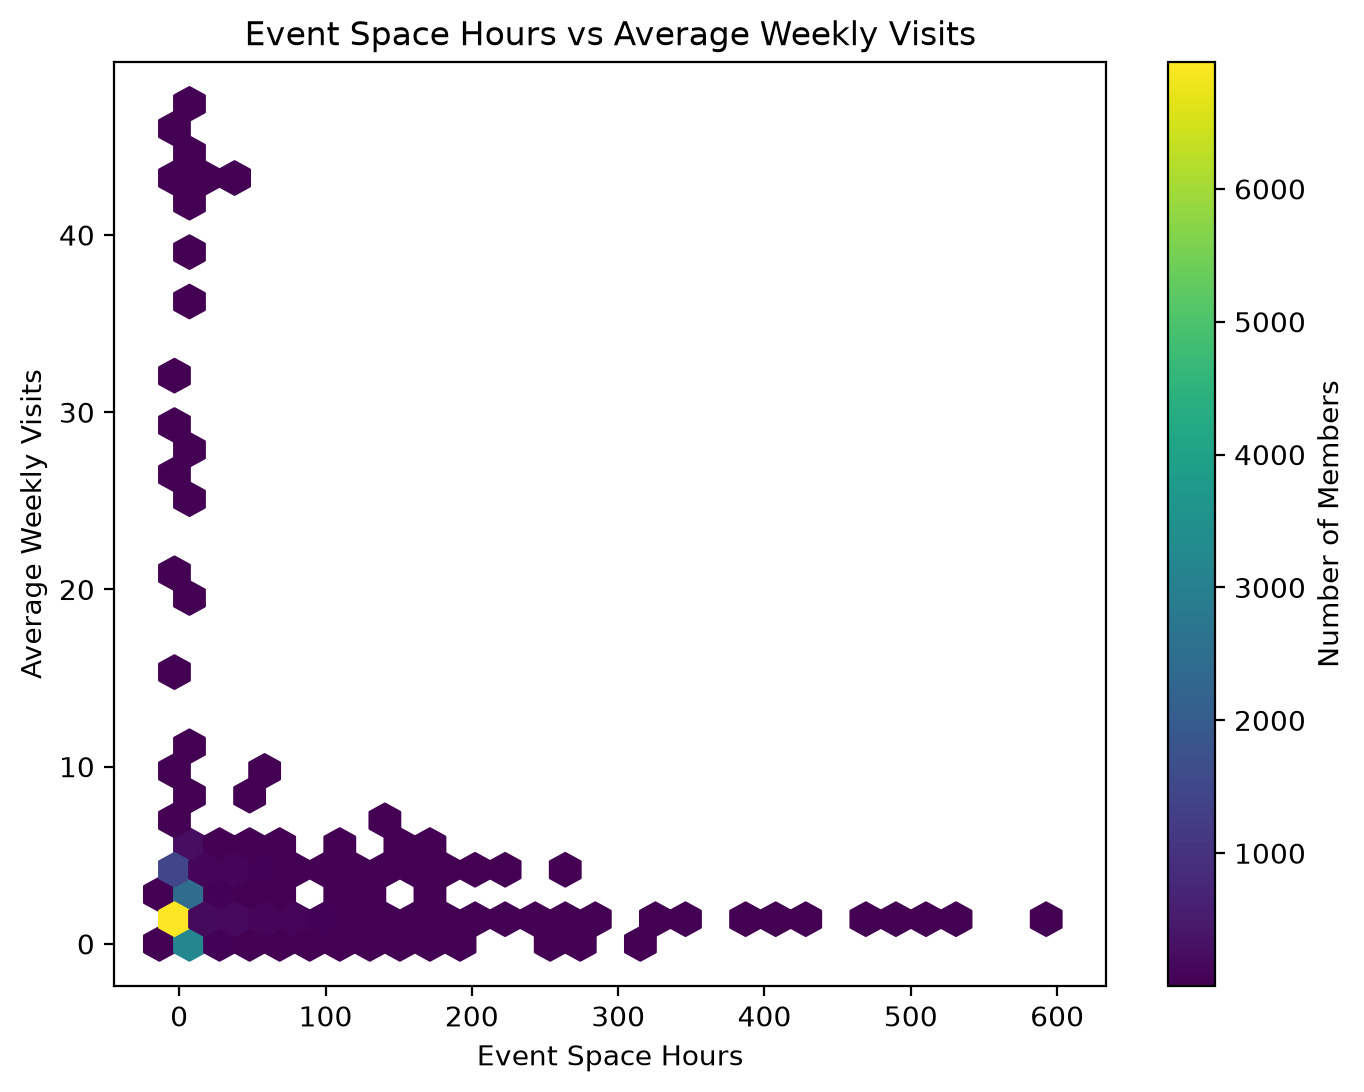

Spearman correlation: 0.07


In [24]:
plt.figure(figsize=(8, 6))

plt.hexbin(
    df["event_space_hours"],
    df["avg_weekly_visits"],
    gridsize=30,
    cmap="viridis",
    mincnt=1
)

plt.xlabel("Event Space Hours")
plt.ylabel("Average Weekly Visits")
plt.title("Event Space Hours vs Average Weekly Visits")

plt.colorbar(label="Number of Members")
plt.show()

rho = df["event_space_hours"].corr(df["avg_weekly_visits"], method="spearman")
print("Spearman correlation:", round(rho, 2))

Event-space usage shows little evidence of a strong monotonic relationship with average weekly visits. Most members have low values for both variables, while high event-space usage is mainly associated with low weekly visits. This suggests that event-space hours may capture a different behavioral dimension from regular workspace attendance.